In [1]:
# ============================================================
# TRILIT AI – PRODUCTION NOTEBOOK (Kaggle T4 x2)
# CELL 1 : INSTALL LIBRARIES & FETCH ALL SCREENING DATA
# ============================================================

# 1. Install required packages (faiss for search, transformers for LLMs, etc.)
!pip install -q faiss-cpu sentence-transformers transformers scikit-learn

# 2. Imports needed only for this cell
import os, urllib.request, pandas as pd

# 3. Define all datasets (human‑labeled systematic reviews)
DATASETS = {
    "ACEInhibitors.csv": "https://raw.githubusercontent.com/asreview/systematic-review-datasets/metadata-v1-final/datasets/Cohen_2006/output/online/ACEInhibitors.csv",
    "Statins.csv": "https://raw.githubusercontent.com/asreview/systematic-review-datasets/metadata-v1-final/datasets/Cohen_2006/output/online/Statins.csv",
    "CalciumChannelBlockers.csv": "https://raw.githubusercontent.com/asreview/systematic-review-datasets/metadata-v1-final/datasets/Cohen_2006/output/online/CalciumChannelBlockers.csv",
    "AtypicalAntipsychotics.csv": "https://raw.githubusercontent.com/asreview/systematic-review-datasets/metadata-v1-final/datasets/Cohen_2006/output/online/AtypicalAntipsychotics.csv",
    "ADHD.csv": "https://raw.githubusercontent.com/asreview/systematic-review-datasets/metadata-v1-final/datasets/Cohen_2006/output/online/ADHD.csv",
    "BetaBlockers.csv": "https://raw.githubusercontent.com/asreview/systematic-review-datasets/metadata-v1-final/datasets/Cohen_2006/output/online/BetaBlockers.csv",
    "NSAIDS.csv": "https://raw.githubusercontent.com/asreview/systematic-review-datasets/metadata-v1-final/datasets/Cohen_2006/output/online/NSAIDS.csv",
    "ProtonPumpInhibitors.csv": "https://raw.githubusercontent.com/asreview/systematic-review-datasets/metadata-v1-final/datasets/Cohen_2006/output/online/ProtonPumpInhibitors.csv",
    "OralHypoglycemics.csv": "https://raw.githubusercontent.com/asreview/systematic-review-datasets/metadata-v1-final/datasets/Cohen_2006/output/online/OralHypoglycemics.csv",
    "Appenzeller-Herzog_2020.csv": "https://raw.githubusercontent.com/asreview/systematic-review-datasets/metadata-v1-final/datasets/Appenzeller-Herzog_2020/output/Appenzeller-Herzog_2020.csv",
    "Bannach-Brown_2019.csv": "https://raw.githubusercontent.com/asreview/systematic-review-datasets/metadata-v1-final/datasets/Bannach-Brown_2019/output/Bannach-Brown_2019.csv",
    "Bos_2018.csv": "https://raw.githubusercontent.com/asreview/systematic-review-datasets/metadata-v1-final/datasets/Bos_2018/output/Bos_2018.csv"
}

COMBINED_PATH = '/kaggle/working/screening_data/combined_systematic_reviews.csv'
os.makedirs('/kaggle/working/screening_data', exist_ok=True)

# 4. Download & merge if not already done
if not os.path.exists(COMBINED_PATH):
    all_dfs = []
    for fname, url in DATASETS.items():
        print(f"Downloading {fname} …")
        local = f"/kaggle/working/screening_data/{fname}"
        urllib.request.urlretrieve(url, local)
        df = pd.read_csv(local, low_memory=False)
        df = df.dropna(subset=['title','abstract'])
        df['label'] = df['label_included'].astype(int)
        df['TITLE'] = df['title']
        df['ABSTRACT'] = df['abstract']
        all_dfs.append(df[['TITLE','ABSTRACT','label']])
        print(f"   {len(df)} papers (included: {df['label'].sum()})")
    combined = pd.concat(all_dfs, ignore_index=True)
    combined.to_csv(COMBINED_PATH, index=False)
    print(f"\n✅ Combined dataset saved – {len(combined)} papers total.")
else:
    print("✅ Combined dataset already exists.")

print("\n✅ Cell 1 complete – packages and data ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 69.7 MB/s eta 0:00:00
   2214 papers (included: 40)
   2659 papers (included: 81)
   1069 papers (included: 91)
   999 papers (included: 144)
   781 papers (included: 19)
   1819 papers (included: 41)
   348 papers (included: 40)
   1171 papers (included: 50)
   462 papers (included: 131)
   2358 papers (included: 26)
   1599 papers (included: 251)
   5609 papers (included: 11)

✅ Combined dataset saved – 21088 papers total.

✅ Cell 1 complete – packages and data ready.


In [2]:
# ============================================================
# TRILIT AI – PRODUCTION NOTEBOOK (Kaggle T4 x2)
# CELL 2 : IMPORT LIBRARIES & VERIFY DATA LOCATIONS
# ============================================================
import pandas as pd
import numpy as np
import json, os, faiss, torch
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from transformers import (
    BartTokenizer, BartForConditionalGeneration,
    AutoTokenizer, AutoModelForSequenceClassification,
    AutoConfig, get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split

# Confirm GPU
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU device    :", torch.cuda.get_device_name(0))
    print("GPU count     :", torch.cuda.device_count())

# Paths
ARXIV_PATH = '/kaggle/input/datasets/organizations/Cornell-University/arxiv/arxiv-metadata-oai-snapshot.json'
ISA_PATH   = '/kaggle/working/screening_data/combined_systematic_reviews.csv'

print("\nArXiv JSON exists:", os.path.exists(ARXIV_PATH))
print("Combined screening CSV exists:", os.path.exists(ISA_PATH))

print("\n✅ Cell 2 complete – libraries imported, paths verified.")

CUDA available: True
GPU device    : Tesla T4
GPU count     : 2

ArXiv JSON exists: True
Combined screening CSV exists: True

✅ Cell 2 complete – libraries imported, paths verified.


In [3]:
# ============================================================
# TRILIT AI – PRODUCTION NOTEBOOK (Kaggle T4 x2)
# CELL 3 : LOAD, CLEAN, AND EXPLORE BOTH DATASETS
# ============================================================
import pandas as pd
import json
import os

# ----------------------------------------------------------
# 1. LOAD & CLEAN SYSTEMATIC REVIEW SCREENING DATASET
# ----------------------------------------------------------
print("=" * 60)
print("1. SYSTEMATIC REVIEW SCREENING DATASET (Combined)")
print("=" * 60)

df_screen = pd.read_csv(ISA_PATH, low_memory=False)
print(f"Original shape: {df_screen.shape}")

# Remove rows with missing TITLE or ABSTRACT
df_screen = df_screen.dropna(subset=['TITLE', 'ABSTRACT'])
print(f"After dropping missing TITLE/ABSTRACT: {len(df_screen)} rows")

# Remove rows with empty strings
df_screen = df_screen[
    (df_screen['TITLE'].str.strip() != '') & 
    (df_screen['ABSTRACT'].str.strip() != '')
]
print(f"After removing empty strings: {len(df_screen)} rows")

# Create a combined text field
df_screen['text'] = df_screen['TITLE'].str.strip() + '. ' + df_screen['ABSTRACT'].str.strip()

# Ensure label is integer
df_screen['label'] = df_screen['label'].astype(int)

# Label distribution
print("\nLabel distribution:")
label_counts = df_screen['label'].value_counts()
print(label_counts)
if 1 in label_counts:
    print(f"Imbalance ratio (Exclude : Include) = 1 : {label_counts[0] / label_counts[1]:.1f}")
else:
    print("WARNING: No 'Include' labels found!")

# Show sample
print("\nSample Include paper (first 300 chars):")
include_sample = df_screen[df_screen['label'] == 1]['text'].iloc[0][:300]
print(include_sample + "...")

# ----------------------------------------------------------
# 2. LOAD A SUBSET OF ARXIV PAPERS (for ScholarSort)
# ----------------------------------------------------------
print("\n" + "=" * 60)
print("2. ARXIV DATASET")
print("=" * 60)

N_ARXIV = 50000   # Will be trimmed after cleaning
papers = []
with open(ARXIV_PATH, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= N_ARXIV:
            break
        try:
            data = json.loads(line)
            papers.append({
                'id': data.get('id', ''),
                'title': data.get('title', '').strip(),
                'categories': data.get('categories', ''),
                'abstract': data.get('abstract', '').strip()
            })
        except:
            continue

df_arxiv = pd.DataFrame(papers)
print(f"Loaded {len(df_arxiv)} papers (before cleaning)")

# Drop rows with missing title/abstract
df_arxiv.dropna(subset=['title', 'abstract'], inplace=True)
df_arxiv.reset_index(drop=True, inplace=True)

# Remove empty strings
df_arxiv = df_arxiv[
    (df_arxiv['title'].str.strip() != '') &
    (df_arxiv['abstract'].str.strip() != '')
]
df_arxiv.reset_index(drop=True, inplace=True)
print(f"After cleaning: {len(df_arxiv)} papers")

# Create combined text for embeddings
df_arxiv['text'] = df_arxiv['title'] + '. ' + df_arxiv['abstract']

print(f"\nAverage abstract length: {df_arxiv['abstract'].str.len().mean():.0f} chars")
print(f"Unique categories: {df_arxiv['categories'].nunique()}")

print("\n✅ Cell 3 complete – data loaded, cleaned, and explored.")

1. SYSTEMATIC REVIEW SCREENING DATASET (Combined)
Original shape: (21088, 3)
After dropping missing TITLE/ABSTRACT: 21088 rows
After removing empty strings: 21088 rows

Label distribution:
label
0    20163
1      925
Name: count, dtype: int64
Imbalance ratio (Exclude : Include) = 1 : 21.8

Sample Include paper (first 300 chars):
Effect of angiotensin converting enzyme inhibition on sudden cardiac death in patients following acute myocardial infarction. A meta-analysis of randomized clinical trials.. Estimate the effect of angiotensin converting enzyme (ACE) inhibitors on the risk of sudden cardiac death (SCD) following myoc...

2. ARXIV DATASET
Loaded 50000 papers (before cleaning)
After cleaning: 50000 papers

Average abstract length: 790 chars
Unique categories: 3872

✅ Cell 3 complete – data loaded, cleaned, and explored.


In [4]:
# ============================================================
# TRILIT AI – PRODUCTION NOTEBOOK (Kaggle T4 x2)
# CELL 4 : CREATE VECTOR EMBEDDINGS FOR ALL ARXIV PAPERS
# ============================================================
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Load the embedding model
embedder = SentenceTransformer('all-MiniLM-L6-v2', device=device)

# Extract the combined text column
texts = df_arxiv['text'].tolist()
print(f"Embedding {len(texts)} papers – this will take ~1.5 minutes on T4...")
embeddings = embedder.encode(texts, show_progress_bar=True, convert_to_numpy=True)
print(f"Embeddings shape: {embeddings.shape}   (papers × dimensions)")

print("✅ Cell 4 complete – embeddings ready.")

Using device: cuda


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding 50000 papers – this will take ~1.5 minutes on T4...


Batches:   0%|          | 0/1563 [00:00<?, ?it/s]

Embeddings shape: (50000, 384)   (papers × dimensions)
✅ Cell 4 complete – embeddings ready.


In [5]:
# ============================================================
# TRILIT AI – PRODUCTION NOTEBOOK (Kaggle T4 x2)
# CELL 5 : BUILD FAISS INDEX AND SAVE ALL SEARCH FILES
# ============================================================
dim = embeddings.shape[1]
index = faiss.IndexFlatL2(dim)
index.add(embeddings)
print(f"FAISS index size: {index.ntotal} vectors")

# Save index, metadata, and embeddings to /kaggle/working
faiss.write_index(index, '/kaggle/working/arxiv_faiss.index')
df_arxiv.to_csv('/kaggle/working/arxiv_metadata.csv', index=False)
np.save('/kaggle/working/arxiv_embeddings.npy', embeddings)

print("Files saved to /kaggle/working:")
print("  - arxiv_faiss.index")
print("  - arxiv_metadata.csv")
print("  - arxiv_embeddings.npy")

print("✅ Cell 5 complete – FAISS index saved.")

FAISS index size: 50000 vectors
Files saved to /kaggle/working:
  - arxiv_faiss.index
  - arxiv_metadata.csv
  - arxiv_embeddings.npy
✅ Cell 5 complete – FAISS index saved.


In [6]:
# ============================================================
# TRILIT AI – PRODUCTION NOTEBOOK (Kaggle T4 x2)
# CELL 6 : SCHOLARSORT – SEMANTIC SEARCH FUNCTION & TEST
# ============================================================

def search_papers(query, k=10):
    """
    Encode the query, search the FAISS index,
    and return the top‑k most similar papers.
    """
    q_vec = embedder.encode([query], convert_to_numpy=True)
    distances, indices = index.search(q_vec, k)
    results = df_arxiv.iloc[indices[0]].copy()
    results['score'] = distances[0].round(4)
    return results[['id', 'title', 'categories', 'score']].reset_index(drop=True)

# Test query
test_query = "deep learning for medical image analysis"
print("Query:", test_query)
display(search_papers(test_query, k=5))

print("✅ Cell 6 complete – ScholarSort is working.")

Query: deep learning for medical image analysis


,id,title,categories,score
0,0704.2728,An automated system for lung nodule detection ...,physics.med-ph,1.1377
1,0707.2696,Automated detection of lung nodules in low-dos...,physics.med-ph,1.1428
2,0705.2011,Multi-Dimensional Recurrent Neural Networks,cs.AI cs.CV,1.1556
3,0705.0781,Medical Image Segmentation and Localization us...,cs.CV,1.2065
4,0706.0300,Automatic Detection of Pulmonary Embolism usin...,cs.CV,1.2390


✅ Cell 6 complete – ScholarSort is working.


In [7]:
# ============================================================
# TRILIT AI – PRODUCTION NOTEBOOK (Kaggle T4 x2)
# CELL 7 : PAPER SUMMARIZER – LOAD BART & GENERATE SUMMARY
# ============================================================
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Loading BART on {device}...")

# Load tokenizer and model
tokenizer_bart = BartTokenizer.from_pretrained("facebook/bart-large-cnn")
model_bart = BartForConditionalGeneration.from_pretrained("facebook/bart-large-cnn")
model_bart.to(device).eval()
print("BART loaded.")

# Pick a sample abstract from the ArXiv subset
sample_abstract = df_arxiv['abstract'].iloc[0]
print("\nOriginal abstract (first 400 chars):")
print(sample_abstract[:400] + "...")

# Tokenize and generate summary
inputs = tokenizer_bart([sample_abstract], max_length=1024, return_tensors="pt", truncation=True)
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    summary_ids = model_bart.generate(
        **inputs,
        max_length=130,
        min_length=30,
        num_beams=4,
        early_stopping=True
    )

summary = tokenizer_bart.decode(summary_ids[0], skip_special_tokens=True)
print("\nGenerated summary:")
print(summary)

print("\n✅ Cell 7 complete – Summarizer ready.")

Loading BART on cuda...


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

BART loaded.

Original abstract (first 400 chars):
A fully differential calculation in perturbative quantum chromodynamics is
presented for the production of massive photon pairs at hadron colliders. All
next-to-leading order perturbative contributions from quark-antiquark,
gluon-(anti)quark, and gluon-gluon subprocesses are included, as well as
all-orders resummation of initial-state gluon radiation valid at
next-to-next-to-leading logarithmic ac...

Generated summary:
A fully differential calculation in perturbative quantum chromodynamics is presented for the production of massive photon pairs at hadron colliders. Good agreement is demonstrated with data from the Fermilab Tevatron, and predictions are made for more detailed tests with CDF and DO data.

✅ Cell 7 complete – Summarizer ready.


In [8]:
# ============================================================
# TRILIT AI – PRODUCTION NOTEBOOK (Kaggle T4 x2)
# CELL 8 : SPLIT SCREENING DATA FOR LITREV‑AI TRAINING
# ============================================================

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df_screen['text'].tolist(),
    df_screen['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df_screen['label']
)

print(f"Training samples:   {len(train_texts)}")
print(f"Validation samples: {len(val_texts)}")
print(f"Train Include: {sum(train_labels):5d}   Exclude: {len(train_labels)-sum(train_labels):5d}")
print(f"Val   Include: {sum(val_labels):5d}   Exclude: {len(val_labels)-sum(val_labels):5d}")

print("\n✅ Cell 8 complete – data split ready.")

Training samples:   16870
Validation samples: 4218
Train Include:   740   Exclude: 16130
Val   Include:   185   Exclude:  4033

✅ Cell 8 complete – data split ready.


In [9]:
# ============================================================
# TRILIT AI – PRODUCTION NOTEBOOK (Kaggle T4 x2)
# CELL 9 : LITREV‑AI – TRAIN PUBMEDBERT FOR PAPER SCREENING
#           Uses Focal Loss, WeightedRandomSampler, and
#           Gradient Clipping to handle extreme imbalance.
# ============================================================
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from transformers import (
    AutoConfig, AutoTokenizer, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.metrics import classification_report
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

# ----------------------------------------------------------
# 1. Focal Loss definition
#    Forces the model to focus on hard, mis‑classified examples.
# ----------------------------------------------------------
class FocalLoss(torch.nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce_loss = torch.nn.functional.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        # alpha weight for class 1 (Include)
        weights = torch.where(targets == 1, self.alpha, 1 - self.alpha)
        return (weights * focal_loss).mean()

# ----------------------------------------------------------
# 2. Dataset class
# ----------------------------------------------------------
class ScreenDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=512):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# ----------------------------------------------------------
# 3. PubMedBERT tokenizer & datasets
# ----------------------------------------------------------
MODEL_NAME = 'microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext'
tokenizer_pubmed = AutoTokenizer.from_pretrained(MODEL_NAME)

train_ds = ScreenDataset(train_texts, train_labels, tokenizer_pubmed)
val_ds   = ScreenDataset(val_texts, val_labels, tokenizer_pubmed)

# WeightedRandomSampler to balance each training batch
class_counts = np.bincount(train_labels)
class_weights_ce = 1.0 / class_counts
sample_weights = class_weights_ce[train_labels]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

BATCH_SIZE = 16
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

# ----------------------------------------------------------
# 4. Model with dropout
# ----------------------------------------------------------
config = AutoConfig.from_pretrained(MODEL_NAME, num_labels=2)
config.hidden_dropout_prob = 0.1
config.attention_probs_dropout_prob = 0.1

model_pubmed = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, config=config)
model_pubmed.to(device)

# Focal Loss (alpha=0.75 gives more weight to the Include class)
criterion = FocalLoss(alpha=0.75, gamma=2.0)

optimizer = AdamW(model_pubmed.parameters(), lr=3e-5, weight_decay=0.01)
EPOCHS = 4
total_steps = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * 0.1)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# ----------------------------------------------------------
# 5. Training loop with gradient clipping
# ----------------------------------------------------------
print("Training PubMedBERT with Focal Loss (4 epochs)...")
for epoch in range(EPOCHS):
    model_pubmed.train()
    total_loss = 0
    steps = len(train_loader)
    for batch_idx, batch in enumerate(train_loader):
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model_pubmed(input_ids, attention_mask=attention_mask)
        loss = criterion(outputs.logits, labels)
        loss.backward()
        # Clip gradients to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model_pubmed.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

        if (batch_idx + 1) % 100 == 0:
            print(f"  Epoch {epoch+1}/{EPOCHS} | Batch {batch_idx+1}/{steps} | Loss: {loss.item():.4f}")

    print(f"Epoch {epoch+1} average training loss: {total_loss/steps:.4f}")

# ----------------------------------------------------------
# 6. Validation & threshold tuning
# ----------------------------------------------------------
print("\nEvaluating on validation set...")
model_pubmed.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model_pubmed(input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1)[:, 1]
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# Find best threshold (maximising F1)
from sklearn.metrics import precision_recall_fscore_support
best_f1 = 0
best_thresh = 0.5
for thresh in np.arange(0.05, 0.95, 0.05):
    preds = (all_probs >= thresh).astype(int)
    _, _, f1, _ = precision_recall_fscore_support(all_labels, preds, average='binary')
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print(f"\nBest F1 threshold: {best_thresh:.2f} (F1 = {best_f1:.4f})")

# Find threshold that gives recall ≥ 85%
target_recall = 0.85
best_rec_thresh = 0.5
for thresh in np.arange(0.05, 0.95, 0.05):
    preds = (all_probs >= thresh).astype(int)
    if preds.sum() > 0:
        rec = all_labels[preds == 1].sum() / all_labels.sum()
        if rec >= target_recall:
            best_rec_thresh = thresh
            break

rec_preds = (all_probs >= best_rec_thresh).astype(int)
rec_actual = all_labels[rec_preds == 1].sum() / all_labels.sum() if rec_preds.sum() > 0 else 0
print(f"Threshold for recall ≥ {target_recall}: {best_rec_thresh:.2f} (actual recall: {rec_actual:.2%})")

# Final report with recall‑optimised threshold
final_preds = (all_probs >= best_rec_thresh).astype(int)
print("\nClassification Report (Recall‑Optimised):")
print(classification_report(all_labels, final_preds, target_names=['Exclude', 'Include']))

# ----------------------------------------------------------
# 7. Save the trained model
# ----------------------------------------------------------
model_pubmed.save_pretrained('/kaggle/working/litrev_model')
tokenizer_pubmed.save_pretrained('/kaggle/working/litrev_model')
print("Improved LitRev‑AI model saved to /kaggle/working/litrev_model")

print("\n✅ Cell 9 complete – LitRev‑AI training finished.")

Training on: cuda


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- 

Training PubMedBERT with Focal Loss (4 epochs)...
  Epoch 1/4 | Batch 100/1055 | Loss: 0.0403
  Epoch 1/4 | Batch 200/1055 | Loss: 0.0206
  Epoch 1/4 | Batch 300/1055 | Loss: 0.0772
  Epoch 1/4 | Batch 400/1055 | Loss: 0.0094
  Epoch 1/4 | Batch 500/1055 | Loss: 0.0116
  Epoch 1/4 | Batch 600/1055 | Loss: 0.0322
  Epoch 1/4 | Batch 700/1055 | Loss: 0.0272
  Epoch 1/4 | Batch 800/1055 | Loss: 0.0094
  Epoch 1/4 | Batch 900/1055 | Loss: 0.0016
  Epoch 1/4 | Batch 1000/1055 | Loss: 0.0149
Epoch 1 average training loss: 0.0280
  Epoch 2/4 | Batch 100/1055 | Loss: 0.0010
  Epoch 2/4 | Batch 200/1055 | Loss: 0.0054
  Epoch 2/4 | Batch 300/1055 | Loss: 0.0317
  Epoch 2/4 | Batch 400/1055 | Loss: 0.0009
  Epoch 2/4 | Batch 500/1055 | Loss: 0.0015
  Epoch 2/4 | Batch 600/1055 | Loss: 0.0020
  Epoch 2/4 | Batch 700/1055 | Loss: 0.0453
  Epoch 2/4 | Batch 800/1055 | Loss: 0.0029
  Epoch 2/4 | Batch 900/1055 | Loss: 0.0004
  Epoch 2/4 | Batch 1000/1055 | Loss: 0.0167
Epoch 2 average training loss:

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Improved LitRev‑AI model saved to /kaggle/working/litrev_model

✅ Cell 9 complete – LitRev‑AI training finished.


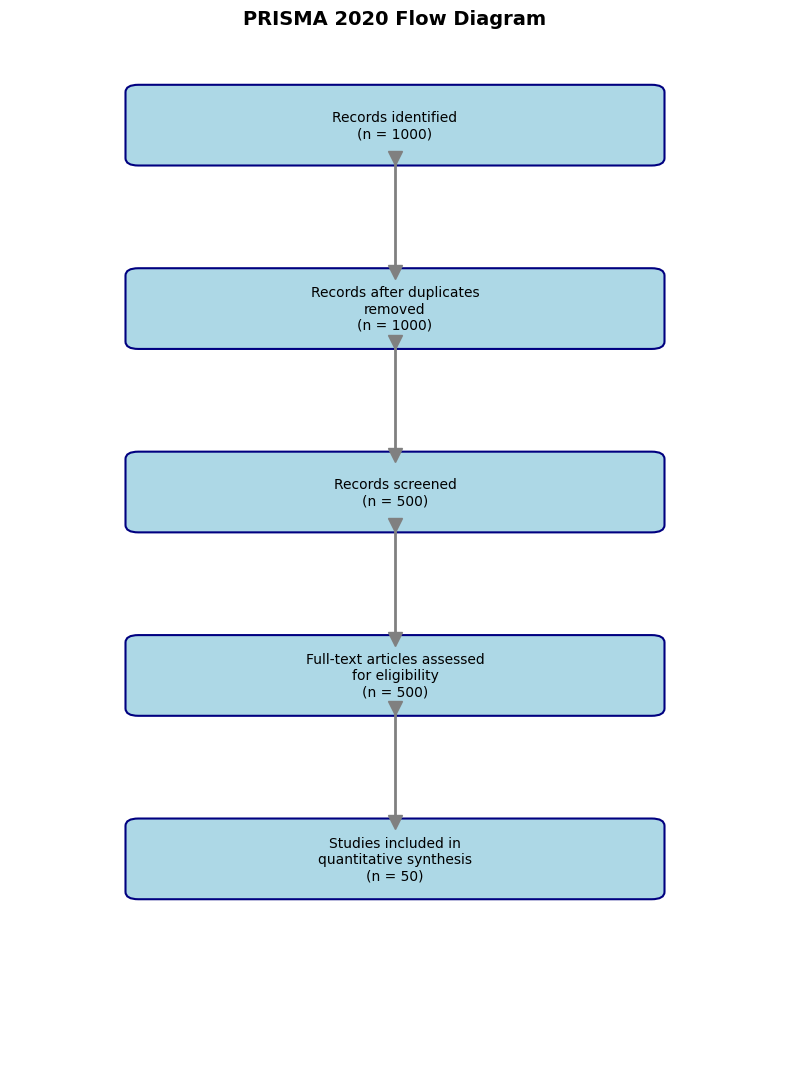

✅ Diagram saved as:
   PNG: /kaggle/working/prisma_flow.png
   PDF: /kaggle/working/prisma_flow.pdf
✅ Cell 10 complete


In [10]:
# ============================================================
# TRILIT AI – PRODUCTION NOTEBOOK (Kaggle T4 x2)
# CELL 10 : GENERATE A CLEAN PRISMA 2020 FLOW DIAGRAM
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

def draw_prisma(total, screened, included,
                filename_png='/kaggle/working/prisma_flow.png',
                filename_pdf='/kaggle/working/prisma_flow.pdf'):
    fig, ax = plt.subplots(figsize=(8, 11))
    ax.set_xlim(0, 6)
    ax.set_ylim(0, 14)
    ax.axis('off')

    boxes = [
        ("Records identified", total, 13),
        ("Records after duplicates\nremoved", total, 10.5),
        ("Records screened", screened, 8),
        ("Full‑text articles assessed\nfor eligibility", screened, 5.5),
        ("Studies included in\nquantitative synthesis", included, 3)
    ]

    box_w, box_h = 4.0, 0.9

    for (label, count, y_pos) in boxes:
        rect = mpatches.FancyBboxPatch((1, y_pos - box_h/2), box_w, box_h,
                                       boxstyle="round,pad=0.1",
                                       facecolor='lightblue', edgecolor='navy', linewidth=1.5)
        ax.add_patch(rect)
        text = f"{label}\n(n = {count})"
        ax.text(1 + box_w/2, y_pos, text, ha='center', va='center',
                fontsize=10, fontweight='medium')

    arrow_y_pairs = [(12.55, 11.0), (10.05, 8.5), (7.55, 6.0), (5.05, 3.5)]
    for y_from, y_to in arrow_y_pairs:
        ax.add_line(mlines.Line2D([3, 3], [y_from, y_to], color='gray', linewidth=2,
                                  marker='v', markersize=10, markerfacecolor='gray'))

    plt.title("PRISMA 2020 Flow Diagram", fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig(filename_png, dpi=150, bbox_inches='tight')
    plt.savefig(filename_pdf, bbox_inches='tight')
    plt.show()
    print("✅ Diagram saved as:")
    print(f"   PNG: {filename_png}")
    print(f"   PDF: {filename_pdf}")

# Example usage
draw_prisma(total=1000, screened=500, included=50)

print("✅ Cell 10 complete")

In [11]:
# ============================================================
# TRILIT AI – PRODUCTION NOTEBOOK (Kaggle T4 x2)
# CELL 11 : END‑TO‑END DEMONSTRATION
# ============================================================

# 1. Search
query = "transformer models for medical text"
print("Search results:")
results = search_papers(query, k=3)
display(results[['id', 'title', 'score']])

# 2. Summarise top paper
top_id = results.iloc[0]['id']
top_abs = df_arxiv[df_arxiv['id'] == top_id]['abstract'].values[0]
inputs = tokenizer_bart([top_abs], max_length=1024, return_tensors="pt", truncation=True)
inputs = {k: v.to(device) for k, v in inputs.items()}
summary_ids = model_bart.generate(**inputs, max_length=130, min_length=30,
                                  num_beams=4, early_stopping=True)
summary = tokenizer_bart.decode(summary_ids[0], skip_special_tokens=True)
print("\nSummary of top result:")
print(summary)

# 3. Screening example (showing probabilities, not just include/exclude)
dummy_texts = [
    "A novel BERT model for drug interaction extraction from clinical notes.",
    "Effects of climate change on polar bear populations in the Arctic.",
    "Transformer‑based classification of skin lesions from dermoscopic images."
]
enc = tokenizer_pubmed(dummy_texts, truncation=True, padding=True, return_tensors='pt').to(device)
with torch.no_grad():
    probs = torch.softmax(model_pubmed(**enc).logits, dim=1)[:, 1].cpu().numpy()
print("\nScreening examples (higher score = more likely relevant):")
for text, prob in zip(dummy_texts, probs):
    print(f"  Score: {prob:.3f} – {text[:80]}...")

print("\n✅ TriLit AI demonstration complete!")

Search results:


,id,title,score
0,0709.4015,From Texts to Structured Documents: The Case o...,1.1817
1,0706.1137,Automatically Restructuring Practice Guideline...,1.2150
2,0707.3270,A Formal Model of Dictionary Structure and Con...,1.2657



Summary of top result:
This paper describes a system capable of semi-automatically filling an XMLtemplate from free texts in the clinical domain. We show that the system yields good performance when applied to the analysis of French practice guidelines.

Screening examples (higher score = more likely relevant):
  Score: 0.097 – A novel BERT model for drug interaction extraction from clinical notes....
  Score: 0.266 – Effects of climate change on polar bear populations in the Arctic....
  Score: 0.032 – Transformer‑based classification of skin lesions from dermoscopic images....

✅ TriLit AI demonstration complete!


In [12]:
# ============================================================
# TRILIT AI – PRODUCTION NOTEBOOK (Kaggle T4 x2)
# CELL 12 : ZIP ALL OUTPUT FILES FOR THE DESKTOP APP
# ============================================================
import os, zipfile

# Files and folders to include
items = [
    "/kaggle/working/arxiv_faiss.index",
    "/kaggle/working/arxiv_metadata.csv",
    "/kaggle/working/arxiv_embeddings.npy",
    "/kaggle/working/litrev_model",               # entire folder
    "/kaggle/working/prisma_flow.png",
    "/kaggle/working/prisma_flow.pdf"
]

zip_path = "/kaggle/working/trilit_ai_vscode.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for item in items:
        if os.path.isdir(item):
            # Walk through the directory and add all files
            for root, dirs, files in os.walk(item):
                for file in files:
                    full_path = os.path.join(root, file)
                    arcname = os.path.relpath(full_path, "/kaggle/working")
                    zf.write(full_path, arcname)
        elif os.path.isfile(item):
            arcname = os.path.basename(item)
            zf.write(item, arcname)
        else:
            print(f"⚠️  Missing: {item}")

print("✅ ZIP archive created:")
print(f"   {zip_path}")
print("\n📥 To download: click the 'Output' tab on the right sidebar,")
print("   then click the three dots next to 'trilit_ai_vscode.zip' → Download.")

✅ ZIP archive created:
   /kaggle/working/trilit_ai_vscode.zip

📥 To download: click the 'Output' tab on the right sidebar,
   then click the three dots next to 'trilit_ai_vscode.zip' → Download.
